In [1]:
import pandas as pd

df = pd.read_csv("googleplaystore.csv")



In [2]:
df.shape


(10841, 13)

In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [5]:
df.dtypes


App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [6]:
df.head()


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
## Initial Observations
- The dataset contains 10841 rows and 13 columns.
- The columns include App, Category, Rating, Reviews, Size, Installs, Type, Price, Content Rating, Genres, Last Updated, Current Ver, and Android Ver.
- Some coloumns have missing values.
-Columns like Installs and Price include non-numeric characters that need to be cleaned for analysis.
-There are many text heavy coloumns that may not be suitable for machine learning models without significant transformation.

In [7]:
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
}).sort_values(by="Missing Percentage", ascending=False)

missing_summary

,Missing Values,Missing Percentage
Rating,1474,13.596532
Current Ver,8,0.073794
Android Ver,3,0.027673
Content Rating,1,0.009224
Type,1,0.009224
Size,0,0.000000
Reviews,0,0.000000
Category,0,0.000000
App,0,0.000000
Price,0,0.000000


In [ ]:
### Missing Value Handling Decisions

Based on the missing value percentages and the meaning of each column,
different strategies are chosen instead of applying a single uniform
approach.

- **Rating**: Missing values are kept as-is because they may represent
  newly launched apps that have not yet received user feedback.

- **Type**: Missing values are filled with the most frequent value, as
  this column has very few missing entries and represents a categorical
  distinction between Free and Paid apps.

  - **Content Rating**: Missing values are filled with a constant value
  such as "Unknown" to preserve rows while clearly indicating missing
  information.

  - **Current Ver** and **Android Ver**: These columns have a relatively
  high number of missing values and are not critical for core analysis,
  so they are dropped to reduce noise.

In [ ]:
-Fill missing values in Type with the most frequent value
df["Type"].fillna(df["Type"].mode()[0], inplace=True)

-Fill missing values in Content Rating with a constant
df["Content Rating"].fillna("Unknown", inplace=True)

 -Drop columns with high missing values and low analytical importance
df.drop(columns=["Current Ver", "Android Ver"], inplace=True)

In [8]:

df.isnull().sum()


App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [ ]:
## Task 3: Outliers – Think Before Touching

In this task, I identify outliers in numeric columns using the IQR
method. Instead of applying outlier removal uniformly across all
columns, I intentionally select only one column for treatment and
justify why other columns are left untouched.


In [9]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
numeric_columns

Index(['Rating'], dtype='object')

In [10]:
outlier_summary = {}

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = outliers.shape[0]

outlier_summary

{'Rating': 504}

In [ ]:
### Outlier Handling Decision

The **Reviews** column is selected for outlier treatment. This column
contains extremely high values for a small number of very popular apps,
which can disproportionately influence statistical analysis and
visualizations.



In [9]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
numeric_columns


Index(['Rating'], dtype='object')

In [10]:
outlier_summary = {}

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outlier_summary[col] = df[(df[col] < lower) | (df[col] > upper)].shape[0]

outlier_summary


{'Rating': 504}

In [ ]:
## Task 4: Data Type Fixing

Several columns in the dataset are stored as incorrect data types due to
the presence of symbols, text units, or mixed values.

In this task, such columns are identified and converted into appropriate numeric formats.

In [11]:
df.dtypes


App                object
Category           object
Rating            float64
Reviews            object
Size               object
Installs           object
Type               object
Price              object
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

In [12]:
# Fix Installs column: remove '+' and commas, then convert to numeric
df["Installs"] = df["Installs"].astype(str)
df["Installs"] = df["Installs"].str.replace("+", "", regex=False)
df["Installs"] = df["Installs"].str.replace(",", "", regex=False)
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

df["Installs"].dtype


dtype('float64')

In [13]:
# Fix Price column: remove '$' and convert to numeric
df["Price"] = df["Price"].astype(str)
df["Price"] = df["Price"].str.replace("$", "", regex=False)
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Price"].dtype


dtype('float64')

In [14]:


def convert_size(size):
    if isinstance(size, str):
        size = size.strip()
        if size.endswith("M"):
            return float(size.replace("M", ""))
        elif size.endswith("k"):
            return float(size.replace("k", "")) / 1024
        elif size == "Varies with device":
            return None
    return None

df["Size"] = df["Size"].apply(convert_size)

df["Size"].dtype


dtype('float64')

In [ ]:
### Importance of Correct Data Types

# Incorrect data types can severely impact data analysis and machine
# learning workflows. When numeric values are stored as text, operations
# such as sorting, filtering, aggregation, and statistical calculations
# produce incorrect or misleading results.

# Machine learning models require numeric
# inputs, and improperly typed columns may either be ignored or introduce
# errors during training.



In [ ]:
## Task 5: Exploratory Data Analysis (EDA)

# In this task, exploratory data analysis is performed to understand
# patterns, trends, and relationships within the dataset. Visualizations
# are used to gain insights into app popularity, pricing behavior, and
# user ratings.


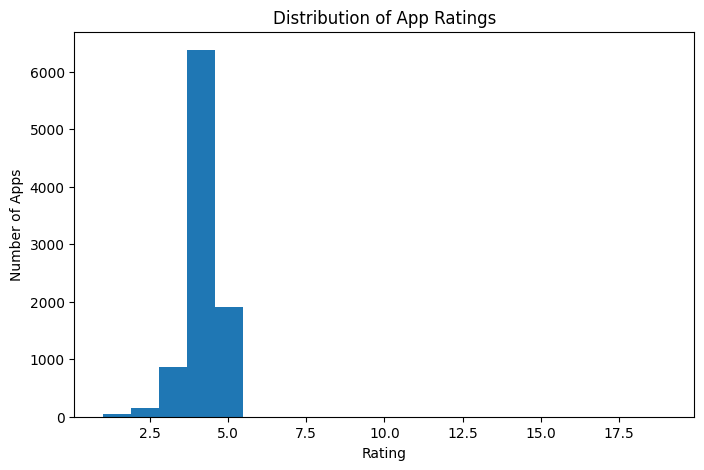

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["Rating"].dropna(), bins=20)
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.title("Distribution of App Ratings")
plt.show()


In [ ]:
### Distribution of App Ratings – Interpretation

# The distribution of app ratings shows that most applications are
# concentrated between ratings of approximately 4.0 and 4.5. This suggests
# that the majority of apps on the Play Store receive generally positive
# user feedback. Extremely low ratings are relatively rare, indicating
# that poorly performing apps are less common or may not remain popular
# for long.

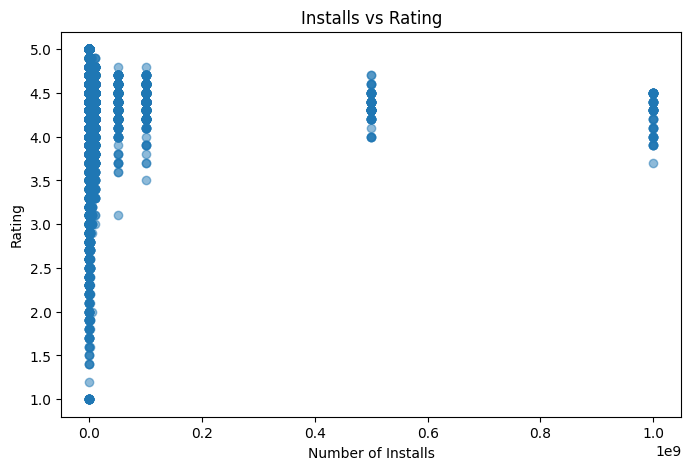

In [17]:

plt.figure(figsize=(8, 5))
plt.scatter(df["Installs"], df["Rating"], alpha=0.5)
plt.xlabel("Number of Installs")
plt.ylabel("Rating")
plt.title("Installs vs Rating")
plt.show()


In [ ]:
### Installs vs Rating – Interpretation


# The scatter plot shows that apps with a high number of installs tend to
# have ratings clustered around the mid-to-high range, typically between
# 4.0 and 4.5. However, a high install count does not guarantee a higher
# rating, as there is still noticeable variation in ratings among popular
# apps.

# At lower install counts, ratings are more widely spread, suggesting that
# new or less popular apps experience greater variability in user
# feedback.

In [ ]:
# Relationship between Price and Rating
plt.figure(figsize=(8, 5))
plt.scatter(df["Price"], df["Rating"], alpha=0.5)
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()
